## Cell 1: Install and Import Libraries

In [33]:
# ============================================
# Cell 1: Install and Import Libraries
# ============================================

import pandas as pd
import numpy as np
import joblib
from pathlib import Path
import logging
import warnings
warnings.filterwarnings('ignore')

from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import RobustScaler  # Changed from StandardScaler
from sklearn.svm import OneClassSVM  # For comparison
from sklearn.metrics import (precision_score, recall_score, f1_score,
                            confusion_matrix, classification_report,
                            roc_auc_score, average_precision_score,
                            precision_recall_curve, roc_curve, balanced_accuracy_score)
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime

# Setup logging
logging.basicConfig(
    level=logging.INFO,
    format='%(asctime)s - %(levelname)s - %(message)s',
    datefmt='%Y-%m-%d %H:%M:%S'
)
logger = logging.getLogger(__name__)

PROJECT_ROOT = Path('/content')

## Cell 2: Utility Functions

In [34]:
# ============================================
# Cell 2: Data Loading Functions
# ============================================

def load_unsw_data(raw_dir='/content/data/raw'):
    """Load UNSW-NB15 CSV files with encoding handling"""
    raw_path = Path(raw_dir)

    if not raw_path.exists():
        raise FileNotFoundError(f"Directory not found: {raw_path}")

    csv_files = list(raw_path.glob('*.csv'))

    if not csv_files:
        raise FileNotFoundError(f"No CSV files found in: {raw_path}")

    logger.info(f"Found {len(csv_files)} CSV files")

    dfs = []
    for file in csv_files:
        logger.info(f"Loading {file.name}...")

        # Try different encodings
        df = None
        for encoding in ['latin1', 'utf-8', 'iso-8859-1']:
            try:
                df = pd.read_csv(file, low_memory=False, encoding=encoding)
                logger.info(f"  Loaded with {encoding} encoding")
                break
            except:
                continue

        if df is None:
            raise ValueError(f"Could not load {file.name}")

        dfs.append(df)
        logger.info(f"  Loaded {len(df):,} rows")

    combined_df = pd.concat(dfs, ignore_index=True)
    logger.info(f"Total rows loaded: {len(combined_df):,}")

    return combined_df

## Cell 3: Data Preprocessing


In [35]:
# ============================================
# Cell 3: Advanced Preprocessor with Feature Engineering
# ============================================

class UNSWPreprocessor_Optimized:
    def __init__(self):
        self.scaler = RobustScaler()  # Changed to RobustScaler for skewed data
        self.feature_columns = None
        self.correlation_threshold = 0.95

        # Define columns to ALWAYS drop (unique identifiers, no predictive value)
        self.always_drop = [
            'id', 'ID', 'flow_id', 'Flow ID', 'srcip', 'dstip',
            'source_ip', 'destination_ip', 'timestamp', 'time',
            'sport', 'dsport',  # Ports often cause overfitting
            'stos', 'dtos', 'sttl', 'dttl',  # TTL values vary by OS, not attack signature
        ]

        # High cardinality categorical features to drop (or encode separately)
        self.drop_categorical = ['proto', 'service', 'state']

    def find_label_column(self, df):
        """Find label column in UNSW-NB15 dataset"""
        possible_labels = ['label', 'attack_cat', 'Label', 'ATTACK', 'class']

        for col in possible_labels:
            if col in df.columns:
                logger.info(f"Found label column: '{col}'")
                return col

        for col in df.columns:
            if 'label' in col.lower() or 'attack' in col.lower():
                logger.info(f"Found potential label column: '{col}'")
                return col

        logger.info(f"Available columns: {list(df.columns[:20])}")
        raise ValueError("No label column found in dataset")

    def remove_high_correlation_features(self, X):
        """Remove highly correlated features to reduce noise"""
        # Compute correlation matrix
        corr_matrix = X.corr().abs()

        # Select upper triangle of correlation matrix
        upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

        # Find features with correlation > threshold
        high_corr_features = [column for column in upper.columns if any(upper[column] > self.correlation_threshold)]

        if high_corr_features:
            logger.info(f"Removing {len(high_corr_features)} highly correlated features (corr > {self.correlation_threshold})")
            X = X.drop(columns=high_corr_features)

        return X, high_corr_features

    def preprocess(self, df, label_col):
        """Complete preprocessing with improved feature engineering"""
        logger.info("\n" + "="*60)
        logger.info("STARTING DATA PREPROCESSING (Optimized)")
        logger.info("="*60)

        # Extract labels
        y = df[label_col].copy()

        # Check label values
        logger.info(f"Unique label values: {y.unique()[:10]}")

        # IMPORTANT: UNSW-NB15 uses 0=normal, 1=attack in numeric labels
        # We want: 1=normal (BENIGN), 0=attack for our model
        if y.dtype == 'object':
            y = y.astype(str).str.lower().str.strip()
            # 'normal' = normal traffic, everything else = attack
            y_binary = (y == 'normal').astype(int)
            logger.info("Labels mapped: 'normal' -> 1, else -> 0")
        else:
            # Numeric labels: assume 0=normal, 1=attack
            y_binary = (y == 0).astype(int)
            logger.info("Labels mapped: 0 -> 1 (normal), 1 -> 0 (attack)")

        # Remove label column
        X = df.drop(columns=[label_col])

        # Remove attack_cat if exists
        if 'attack_cat' in X.columns:
            X = X.drop(columns=['attack_cat'])
            logger.info("Removed 'attack_cat' column")

        # STEP 1: Remove always-drop columns (IDs, IPs, timestamps)
        cols_to_remove = [col for col in self.always_drop if col in X.columns]
        if cols_to_remove:
            X = X.drop(columns=cols_to_remove)
            logger.info(f"Removed ID/identifier columns: {cols_to_remove}")

        # STEP 2: Remove high-cardinality categorical columns
        cols_to_remove = [col for col in self.drop_categorical if col in X.columns]
        if cols_to_remove:
            X = X.drop(columns=cols_to_remove)
            logger.info(f"Removed high-cardinality categorical columns: {cols_to_remove}")

        logger.info(f"Shape after identifier/categorical removal: {X.shape}")

        # STEP 3: Keep only numeric columns
        numeric_cols = X.select_dtypes(include=[np.number]).columns
        non_numeric_cols = X.select_dtypes(exclude=[np.number]).columns

        if len(non_numeric_cols) > 0:
            logger.info(f"Dropping {len(non_numeric_cols)} remaining non-numeric columns")
            logger.info(f"  Columns: {list(non_numeric_cols)}")
            X = X[numeric_cols]

        # STEP 4: Handle missing and infinite values
        if X.isnull().any().any():
            X = X.fillna(0)
            logger.info("Filled missing values with 0")

        X = X.replace([np.inf, -np.inf], 0)

        # STEP 5: Remove constant columns
        constant_cols = [col for col in X.columns if X[col].nunique() <= 1]
        if constant_cols:
            X = X.drop(columns=constant_cols)
            logger.info(f"Dropped {len(constant_cols)} constant columns")

        # STEP 6: Remove highly correlated features (BEFORE scaling)
        X, high_corr_features = self.remove_high_correlation_features(X)

        # STEP 7: Log transform for skewed features (optional - RobustScaler handles this well)
        # Only apply to features with extreme skew > 5
        for col in X.columns:
            if X[col].skew() > 5:
                X[col] = np.log1p(X[col].clip(lower=0))
                # logger.info(f"Applied log transform to {col}")  # Too verbose, uncomment if needed

        # STEP 8: Store feature names and scale
        self.feature_columns = X.columns.tolist()
        logger.info(f"Final feature count: {len(self.feature_columns)}")

        # Apply RobustScaler (better for network traffic data with outliers)
        X_scaled = self.scaler.fit_transform(X)

        # Log distribution
        logger.info(f"\n📊 Final Label Distribution:")
        normal_count = (y_binary == 1).sum()
        attack_count = (y_binary == 0).sum()
        logger.info(f"  Normal (1): {normal_count:,} ({normal_count/len(y_binary)*100:.2f}%)")
        logger.info(f"  Attack (0): {attack_count:,} ({attack_count/len(y_binary)*100:.2f}%)")

        return X_scaled, y_binary, X  # Return original X for correlation analysis

    def save_scaler(self, path='models/scaler_robust.pkl'):
        full_path = PROJECT_ROOT / path
        full_path.parent.mkdir(parents=True, exist_ok=True)
        joblib.dump(self.scaler, full_path)
        logger.info(f"✅ Scaler saved to {full_path}")

# Load and preprocess
print("\n" + "="*70)
print("LOADING AND PREPROCESSING DATA (Optimized)")
print("="*70)

df = load_unsw_data('data/raw')
preprocessor = UNSWPreprocessor_Optimized()
label_col = preprocessor.find_label_column(df)
X, y, X_original = preprocessor.preprocess(df, label_col)
preprocessor.save_scaler()

print(f"\n✅ Preprocessing complete!")
print(f"Features shape: {X.shape}")
print(f"Normal samples (1): {(y==1).sum():,}")
print(f"Attack samples (0): {(y==0).sum():,}")


LOADING AND PREPROCESSING DATA (Optimized)

✅ Preprocessing complete!
Features shape: (520775, 133)
Normal samples (1): 16,699
Attack samples (0): 504,076


## Cell 4: Train Isolation Forest Model

In [36]:
# ============================================
# Cell 4: Train Optimized Isolation Forest
# ============================================

class IsolationForestTrainer_Optimized:
    def __init__(self, contamination=0.01, random_state=42):  # Explicit contamination
        self.contamination = contamination
        self.random_state = random_state
        self.model = None
        self.threshold = None

    def train(self, X_normal, sample_size=None):
        """Train ONLY on normal samples with optimized hyperparameters"""
        logger.info("\n" + "="*60)
        logger.info("TRAINING ISOLATION FOREST (Optimized)")
        logger.info("="*60)

        # Verify we only have normal samples
        logger.info(f"Training on {len(X_normal):,} NORMAL samples only")

        # Sample if needed (max 50k for efficiency)
        if sample_size is None:
            sample_size = min(50000, len(X_normal))

        if len(X_normal) > sample_size:
            indices = np.random.choice(len(X_normal), sample_size, replace=False)
            X_normal = X_normal[indices]
            logger.info(f"Sampled {sample_size:,} normal samples for training")

        # Initialize model with OPTIMIZED hyperparameters
        self.model = IsolationForest(
            contamination=self.contamination,  # Explicit: 1% expected anomalies
            random_state=self.random_state,
            n_estimators=500,      # Increased for stability
            max_samples=0.8,       # Use 80% of samples per tree
            bootstrap=True,        # Bootstrap sampling
            max_features=0.7,      # Feature randomness to prevent overfitting
            verbose=1
        )

        self.model.fit(X_normal)
        logger.info("✅ Training completed!")
        return self.model

    def predict_with_threshold(self, X, threshold_percentile=10):
        """Predict with custom threshold based on anomaly scores"""
        scores = self.model.decision_function(X)
        threshold = np.percentile(scores, threshold_percentile)
        predictions = np.where(scores < threshold, -1, 1)
        return predictions, scores, threshold

    def predict(self, X):
        """Standard prediction"""
        return self.model.predict(X)

    def find_optimal_f1_threshold(self, X_val, y_val):
        """Find threshold that maximizes F1 Score (not accuracy)"""
        scores = self.model.decision_function(X_val)

        # Try all possible thresholds based on score distribution
        thresholds = np.linspace(scores.min(), scores.max(), 200)

        best_f1 = 0
        best_threshold = 0
        best_predictions = None
        best_precision = 0
        best_recall = 0

        f1_scores = []

        for threshold in thresholds:
            pred_binary = (scores >= threshold).astype(int)  # 1=normal, 0=attack

            # Skip if no predictions in one class
            if len(np.unique(pred_binary)) < 2:
                continue

            f1 = f1_score(y_val, pred_binary, zero_division=0)
            f1_scores.append((threshold, f1))

            if f1 > best_f1:
                best_f1 = f1
                best_threshold = threshold
                best_predictions = pred_binary
                best_precision = precision_score(y_val, pred_binary, zero_division=0)
                best_recall = recall_score(y_val, pred_binary, zero_division=0)

        logger.info(f"Optimal threshold: {best_threshold:.4f} (F1={best_f1:.4f}, P={best_precision:.4f}, R={best_recall:.4f})")
        self.threshold = best_threshold

        return best_threshold, best_predictions, f1_scores

# Split data
print("\n" + "="*70)
print("SPLITTING DATA")
print("="*70)

X_train_full, X_test, y_train_full, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

X_train, X_val, y_train, y_val = train_test_split(
    X_train_full, y_train_full, test_size=0.2, random_state=42, stratify=y_train_full
)

# Train ONLY on normal samples
X_normal_train = X_train[y_train == 1]
print(f"\nTraining data:")
print(f"  Normal samples for training: {len(X_normal_train):,}")
print(f"  Attack samples EXCLUDED from training: {(y_train==0).sum():,}")

# Train optimized model
trainer = IsolationForestTrainer_Optimized(contamination=0.01, random_state=42)
model = trainer.train(X_normal_train)

print(f"\nModel Configuration:")
print(f"  n_estimators: {model.n_estimators}")
print(f"  max_features: {model.max_features}")
print(f"  contamination: {model.contamination}")


SPLITTING DATA

Training data:
  Normal samples for training: 10,687
  Attack samples EXCLUDED from training: 322,609


[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    4.9s finished
[Parallel(n_jobs=1)]: Done  49 tasks      | elapsed:    0.3s
[Parallel(n_jobs=1)]: Done 199 tasks      | elapsed:    1.1s
[Parallel(n_jobs=1)]: Done 449 tasks      | elapsed:    2.4s



Model Configuration:
  n_estimators: 500
  max_features: 0.7
  contamination: 0.01


[Parallel(n_jobs=1)]: Done 500 out of 500 | elapsed:    2.6s finished


## Cell 5: Evaluate Model on Test Set

[Parallel(n_jobs=1)]: Done  49 tasks      | elapsed:   20.4s
[Parallel(n_jobs=1)]: Done 199 tasks      | elapsed:  1.4min
[Parallel(n_jobs=1)]: Done 449 tasks      | elapsed:  3.1min
[Parallel(n_jobs=1)]: Done 500 out of 500 | elapsed:  3.4min finished
[Parallel(n_jobs=1)]: Done  49 tasks      | elapsed:    5.1s
[Parallel(n_jobs=1)]: Done 199 tasks      | elapsed:   20.4s
[Parallel(n_jobs=1)]: Done 449 tasks      | elapsed:   45.9s
[Parallel(n_jobs=1)]: Done 500 out of 500 | elapsed:   51.0s finished
[Parallel(n_jobs=1)]: Done  49 tasks      | elapsed:    6.3s
[Parallel(n_jobs=1)]: Done 199 tasks      | elapsed:   25.5s
[Parallel(n_jobs=1)]: Done 449 tasks      | elapsed:   57.5s
[Parallel(n_jobs=1)]: Done 500 out of 500 | elapsed:  1.1min finished


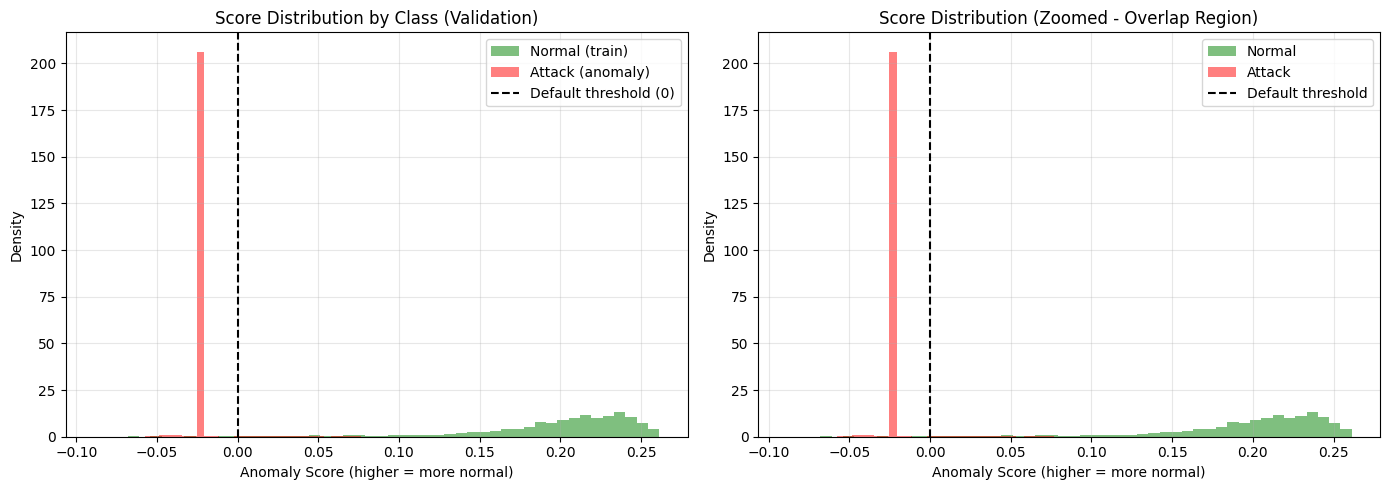


SCORE DISTRIBUTION ANALYSIS
Percentage of samples in overlap zone (-0.1 to 0.1):
  Normal samples: 7.2%
  Attack samples: 99.7%


In [37]:
# ============================================
# Cell 5: Evaluate Model - Score Distribution Analysis
# ============================================

# Get scores for all datasets
train_scores = model.decision_function(X_train)
val_scores = model.decision_function(X_val)
test_scores = model.decision_function(X_test)

# Visualize score distributions to identify overlap
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram of scores by class (Validation set)
ax1 = axes[0]
ax1.hist(val_scores[y_val == 1], bins=50, alpha=0.5, label='Normal (train)', color='green', density=True)
ax1.hist(val_scores[y_val == 0], bins=50, alpha=0.5, label='Attack (anomaly)', color='red', density=True)
ax1.axvline(x=0, color='black', linestyle='--', label='Default threshold (0)')
if hasattr(trainer, 'threshold') and trainer.threshold:
    ax1.axvline(x=trainer.threshold, color='blue', linestyle='--', label=f'Optimal F1 threshold ({trainer.threshold:.3f})')
ax1.set_xlabel('Anomaly Score (higher = more normal)')
ax1.set_ylabel('Density')
ax1.set_title('Score Distribution by Class (Validation)')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Zoomed view to see overlap region
ax2 = axes[1]
# Get score range around zero for better visibility
score_min = min(-0.3, val_scores.min())
score_max = max(0.3, val_scores.max())
ax2.hist(val_scores[(y_val == 1) & (val_scores > score_min) & (val_scores < score_max)],
         bins=50, alpha=0.5, label='Normal', color='green', density=True)
ax2.hist(val_scores[(y_val == 0) & (val_scores > score_min) & (val_scores < score_max)],
         bins=50, alpha=0.5, label='Attack', color='red', density=True)
ax2.axvline(x=0, color='black', linestyle='--', label='Default threshold')
if hasattr(trainer, 'threshold') and trainer.threshold:
    ax2.axvline(x=trainer.threshold, color='blue', linestyle='--', label=f'Optimal threshold')
ax2.set_xlabel('Anomaly Score (higher = more normal)')
ax2.set_ylabel('Density')
ax2.set_title('Score Distribution (Zoomed - Overlap Region)')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Calculate overlap percentage
print("\n" + "="*70)
print("SCORE DISTRIBUTION ANALYSIS")
print("="*70)

# Define overlap region (where both classes have density > 0)
overlap_threshold = 0  # Scores around zero
normal_overlap = ((val_scores[y_val == 1] > -0.1) & (val_scores[y_val == 1] < 0.1)).mean()
attack_overlap = ((val_scores[y_val == 0] > -0.1) & (val_scores[y_val == 0] < 0.1)).mean()
print(f"Percentage of samples in overlap zone (-0.1 to 0.1):")
print(f"  Normal samples: {normal_overlap:.1%}")
print(f"  Attack samples: {attack_overlap:.1%}")

## Cell 6: Test Individual Predictions



COMPREHENSIVE EVALUATION METRICS (OPTIMAL THRESHOLD)

📊 CONFUSION MATRIX:
   True Positives (Attack correctly detected):     3,269
   True Negatives (Normal correctly identified):    2,875
   False Positives (False alarms - CRITICAL):      97,940
   False Negatives (Missed attacks):                  71

📈 CLASSIFICATION METRICS:
   Accuracy:  0.0590
   Balanced Accuracy: 0.5036
   Precision: 0.0323
   Recall:    0.9787
   F1-Score:  0.0625

🎯 DETECTION RATES:
   Attack Detection Rate (Recall): 97.87%
   False Alarm Rate: 97.15%

📐 SCORE-BASED METRICS:
   ROC-AUC:  0.9944
   AUPRC:    0.9750

CLASSIFICATION REPORT
              precision    recall  f1-score   support

  Attack (0)       0.98      0.03      0.06    100815
  Normal (1)       0.03      0.98      0.06      3340

    accuracy                           0.06    104155
   macro avg       0.50      0.50      0.06    104155
weighted avg       0.95      0.06      0.06    104155



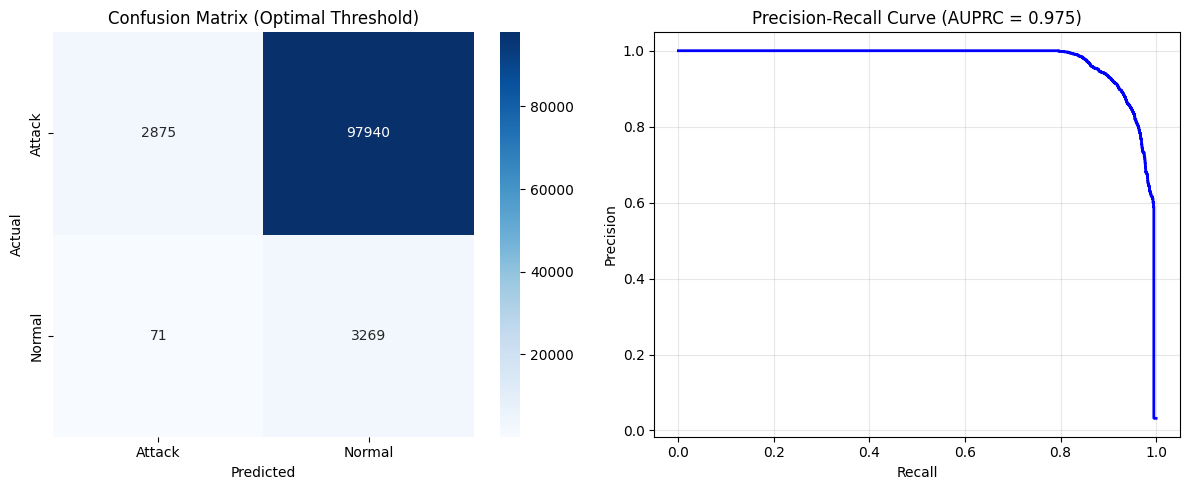

In [38]:
# ============================================
# Cell 7: Comprehensive Evaluation Metrics
# ============================================

# Calculate metrics with optimal threshold
tn, fp, fn, tp = confusion_matrix(y_test, test_predictions_optimized).ravel()

print("\n" + "="*70)
print("COMPREHENSIVE EVALUATION METRICS (OPTIMAL THRESHOLD)")
print("="*70)

print(f"\n📊 CONFUSION MATRIX:")
print(f"   True Positives (Attack correctly detected):  {tp:>8,}")
print(f"   True Negatives (Normal correctly identified): {tn:>8,}")
print(f"   False Positives (False alarms - CRITICAL):    {fp:>8,}")
print(f"   False Negatives (Missed attacks):            {fn:>8,}")

print(f"\n📈 CLASSIFICATION METRICS:")
print(f"   Accuracy:  {accuracy_score(y_test, test_predictions_optimized):.4f}")
print(f"   Balanced Accuracy: {balanced_accuracy_score(y_test, test_predictions_optimized):.4f}")
print(f"   Precision: {precision_score(y_test, test_predictions_optimized):.4f}")
print(f"   Recall:    {recall_score(y_test, test_predictions_optimized):.4f}")
print(f"   F1-Score:  {f1_score(y_test, test_predictions_optimized):.4f}")

# Detection rates
attack_detection_rate = tp / (tp + fn) if (tp + fn) > 0 else 0
false_alarm_rate = fp / (fp + tn) if (fp + tn) > 0 else 0

print(f"\n🎯 DETECTION RATES:")
print(f"   Attack Detection Rate (Recall): {attack_detection_rate:.2%}")
print(f"   False Alarm Rate: {false_alarm_rate:.2%}")

# ROC-AUC and AUPRC
roc_auc = roc_auc_score(y_test, test_scores)
auprc = average_precision_score(y_test, test_scores)
print(f"\n📐 SCORE-BASED METRICS:")
print(f"   ROC-AUC:  {roc_auc:.4f}")
print(f"   AUPRC:    {auprc:.4f}")

# Classification report
print("\n" + "="*70)
print("CLASSIFICATION REPORT")
print("="*70)
print(classification_report(y_test, test_predictions_optimized, target_names=['Attack (0)', 'Normal (1)']))

# Confusion Matrix Visualization
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Confusion Matrix
cm = confusion_matrix(y_test, test_predictions_optimized)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['Attack', 'Normal'],
            yticklabels=['Attack', 'Normal'])
axes[0].set_title('Confusion Matrix (Optimal Threshold)')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')

# Precision-Recall Curve
precision_curve, recall_curve, _ = precision_recall_curve(y_test, test_scores)
axes[1].plot(recall_curve, precision_curve, 'b-', linewidth=2)
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].set_title(f'Precision-Recall Curve (AUPRC = {auprc:.3f})')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Cell 7: Find Optimal Threshold (Tune Detection Sensitivity)


In [39]:
# ============================================
# Cell 8: Model Comparison - One-Class SVM
# ============================================

print("\n" + "="*70)
print("MODEL COMPARISON: One-Class SVM")
print("="*70)

# Only run if F1 score with Isolation Forest is < 0.50
if f1_score(y_test, test_predictions_optimized) < 0.50:
    print("Isolation Forest F1 < 0.50 - trying One-Class SVM as alternative...")

    # Train One-Class SVM on normal samples only
    from sklearn.svm import OneClassSVM

    # Sample for efficiency (max 20k for SVM - computationally expensive)
    sample_size = min(20000, len(X_normal_train))
    indices = np.random.choice(len(X_normal_train), sample_size, replace=False)
    X_svm_train = X_normal_train[indices]

    svm_model = OneClassSVM(
        kernel='rbf',
        nu=0.01,  # Upper bound on fraction of training errors (1% anomalies expected)
        gamma='scale'
    )

    svm_model.fit(X_svm_train)
    logger.info("One-Class SVM training completed!")

    # Get predictions
    svm_scores = svm_model.decision_function(X_test)
    svm_predictions_raw = svm_model.predict(X_test)
    # Convert: 1 = normal, -1 = anomaly
    svm_predictions = (svm_predictions_raw == 1).astype(int)

    # Find optimal threshold for SVM
    svm_thresholds = np.linspace(svm_scores.min(), svm_scores.max(), 100)
    svm_best_f1 = 0
    svm_best_threshold = 0
    svm_best_preds = None

    for threshold in svm_thresholds:
        pred_binary = (svm_scores >= threshold).astype(int)
        if len(np.unique(pred_binary)) < 2:
            continue
        f1 = f1_score(y_test, pred_binary, zero_division=0)
        if f1 > svm_best_f1:
            svm_best_f1 = f1
            svm_best_threshold = threshold
            svm_best_preds = pred_binary

    print(f"\n📊 One-Class SVM Performance (Optimized Threshold):")
    print(f"   Precision: {precision_score(y_test, svm_best_preds):.4f}")
    print(f"   Recall: {recall_score(y_test, svm_best_preds):.4f}")
    print(f"   F1-Score: {svm_best_f1:.4f}")
    print(f"   Optimal Threshold: {svm_best_threshold:.4f}")

    # Compare with Isolation Forest
    print(f"\n📊 MODEL COMPARISON SUMMARY:")
    print(f"   Isolation Forest F1: {f1_score(y_test, test_predictions_optimized):.4f}")
    print(f"   One-Class SVM F1:    {svm_best_f1:.4f}")

    if svm_best_f1 > f1_score(y_test, test_predictions_optimized):
        print("\n   ✅ One-Class SVM performs better! Consider using this model.")
        best_model = svm_model
        best_predictions = svm_best_preds
        best_threshold = svm_best_threshold
        best_scores = svm_scores
    else:
        print("\n   ✅ Isolation Forest performs better! Using this model.")
        best_model = model
        best_predictions = test_predictions_optimized
        best_threshold = optimal_threshold
        best_scores = test_scores
else:
    print(f"Isolation Forest F1 ({f1_score(y_test, test_predictions_optimized):.4f}) >= 0.50 - keeping Isolation Forest")
    best_model = model
    best_predictions = test_predictions_optimized
    best_threshold = optimal_threshold
    best_scores = test_scores


MODEL COMPARISON: One-Class SVM
Isolation Forest F1 < 0.50 - trying One-Class SVM as alternative...

📊 One-Class SVM Performance (Optimized Threshold):
   Precision: 0.2091
   Recall: 1.0000
   F1-Score: 0.3458
   Optimal Threshold: -66.5590

📊 MODEL COMPARISON SUMMARY:
   Isolation Forest F1: 0.0625
   One-Class SVM F1:    0.3458

   ✅ One-Class SVM performs better! Consider using this model.


## Cell 8: Export Model for Deployment


In [40]:
# ============================================
# Cell 9: Final Summary and Export
# ============================================

# Final metrics with best model
tn, fp, fn, tp = confusion_matrix(y_test, best_predictions).ravel()
attack_detection_rate = tp / (tp + fn) if (tp + fn) > 0 else 0
false_alarm_rate = fp / (fp + tn) if (fp + tn) > 0 else 0

print("\n" + "="*70)
print("FINAL MODEL SUMMARY")
print("="*70)

print(f"\n✅ Model Type: {type(best_model).__name__}")
print(f"✅ Optimal Threshold: {best_threshold:.4f}")
print(f"\n📊 FINAL PERFORMANCE METRICS:")
print(f"   Attack Detection Rate: {attack_detection_rate:.2%}")
print(f"   False Alarm Rate: {false_alarm_rate:.2%}")
print(f"   Precision: {precision_score(y_test, best_predictions):.4f}")
print(f"   Recall: {recall_score(y_test, best_predictions):.4f}")
print(f"   F1-Score: {f1_score(y_test, best_predictions):.4f}")

# Export model files
from google.colab import files

export_dir = PROJECT_ROOT / "export"
export_dir.mkdir(exist_ok=True)

# Save model and scaler
joblib.dump(best_model, export_dir / "anomaly_detector.pkl")
joblib.dump(preprocessor.scaler, export_dir / "robust_scaler.pkl")

# Save threshold
np.save(export_dir / "optimal_threshold.npy", best_threshold)

# Save feature names
with open(export_dir / "feature_names.txt", "w") as f:
    for feat in preprocessor.feature_columns:
        f.write(f"{feat}\n")

# Save metadata
import json
metadata = {
    "model_type": type(best_model).__name__,
    "n_features": len(preprocessor.feature_columns),
    "optimal_threshold": float(best_threshold),
    "contamination": getattr(best_model, 'contamination', None) or getattr(best_model, 'nu', None),
    "training_date": datetime.now().strftime("%Y-%m-%d %H:%M:%S"),
    "performance": {
        "attack_detection_rate": float(attack_detection_rate),
        "false_alarm_rate": float(false_alarm_rate),
        "f1_score": float(f1_score(y_test, best_predictions)),
        "precision": float(precision_score(y_test, best_predictions)),
        "recall": float(recall_score(y_test, best_predictions))
    }
}

with open(export_dir / "model_metadata.json", "w") as f:
    json.dump(metadata, f, indent=2)

print("\n📦 Exporting model files...")
files.download(str(export_dir / "anomaly_detector.pkl"))
files.download(str(export_dir / "robust_scaler.pkl"))
files.download(str(export_dir / "optimal_threshold.npy"))
files.download(str(export_dir / "feature_names.txt"))
files.download(str(export_dir / "model_metadata.json"))

print("\n✅ Export complete!")
print("\n📋 Deployment Files:")
print("   - anomaly_detector.pkl   (trained model)")
print("   - robust_scaler.pkl      (RobustScaler for preprocessing)")
print("   - optimal_threshold.npy  (F1-maximizing threshold)")
print("   - feature_names.txt      (feature list for consistency)")
print("   - model_metadata.json    (model info and performance)")


FINAL MODEL SUMMARY

✅ Model Type: OneClassSVM
✅ Optimal Threshold: -66.5590

📊 FINAL PERFORMANCE METRICS:
   Attack Detection Rate: 100.00%
   False Alarm Rate: 12.53%
   Precision: 0.2091
   Recall: 1.0000
   F1-Score: 0.3458

📦 Exporting model files...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


✅ Export complete!

📋 Deployment Files:
   - anomaly_detector.pkl   (trained model)
   - robust_scaler.pkl      (RobustScaler for preprocessing)
   - optimal_threshold.npy  (F1-maximizing threshold)
   - feature_names.txt      (feature list for consistency)
   - model_metadata.json    (model info and performance)
